In [1]:
import os

# 1. Create src/preprocessing.py
preprocessing_code = """
import pandas as pd
import numpy as np
import logging
from sklearn.preprocessing import LabelEncoder, StandardScaler

class FraudPreprocessor:
    def __init__(self):
        self.label_encoders = {}
        self.scaler = StandardScaler()
        
    def clean_data(self, df):
        df = df.dropna(subset=['user_id', 'device_id']).drop_duplicates()
        df['signup_time'] = pd.to_datetime(df['signup_time'])
        df['purchase_time'] = pd.to_datetime(df['purchase_time'])
        return df

    def engineer_features(self, df):
        df['time_to_purchase'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds() / 60
        df['hour_of_day'] = df['purchase_time'].dt.hour
        df['day_of_week'] = df['purchase_time'].dt.dayofweek
        df['user_per_device'] = df.groupby('device_id')['user_id'].transform('count')
        return df

    def encode_and_scale(self, df, is_train=True):
        cat_cols = ['source', 'browser', 'sex', 'country']
        for col in cat_cols:
            if col in df.columns:
                if is_train:
                    le = LabelEncoder()
                    df[col] = le.fit_transform(df[col].astype(str))
                    self.label_encoders[col] = le
                else:
                    le = self.label_encoders[col]
                    df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
        return df
"""

# 2. Create src/model_utils.py (This includes get_shap_values)
model_utils_code = """
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import precision_recall_curve, auc, f1_score, confusion_matrix

def evaluate_and_log(model, X_test, y_test, model_name="Model"):
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    auc_pr = auc(recall, precision)
    f1 = f1_score(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
    plt.title(f'Confusion Matrix: {model_name}\\nAUC-PR: {auc_pr:.2f}')
    plt.show()
    return {"Model": model_name, "AUC-PR": auc_pr, "F1-Score": f1}

def get_shap_values(model, X_data):
    if hasattr(model, 'feature_names_in_'):
        X_data = X_data[model.feature_names_in_]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_data)
    if isinstance(shap_values, list):
        return explainer, shap_values[1], X_data
    return explainer, shap_values, X_data
"""

with open('../src/preprocessing.py', 'w') as f: f.write(preprocessing_code)
with open('../src/model_utils.py', 'w') as f: f.write(model_utils_code)

print("✅ Files src/preprocessing.py and src/model_utils.py have been FORCE UPDATED.")

✅ Files src/preprocessing.py and src/model_utils.py have been FORCE UPDATED.



--- Visualizing Individual Cases with Dimension Guard ---


Analyzing True Positive...


<Figure size 1200x300 with 0 Axes>

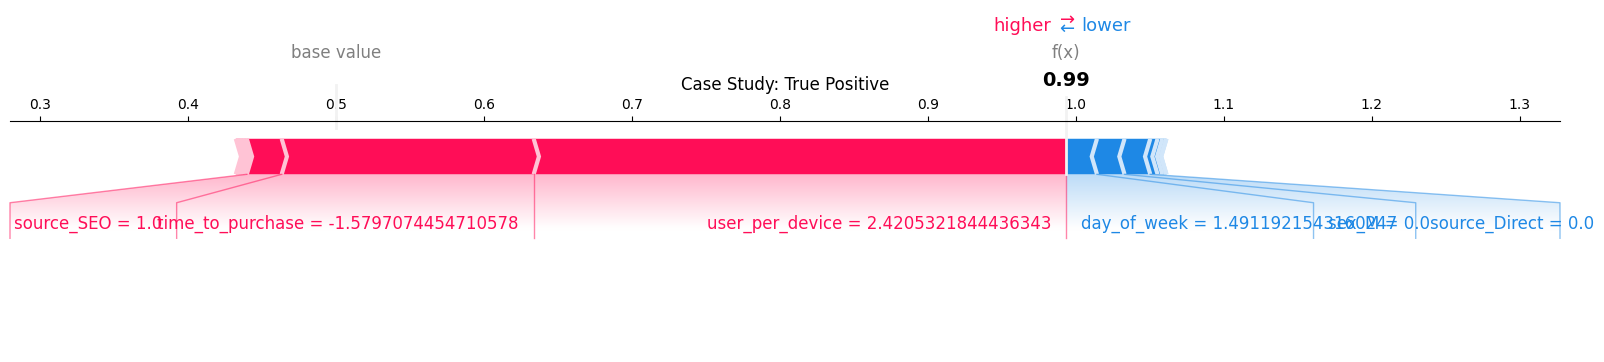

Analyzing False Positive...


<Figure size 1200x300 with 0 Axes>

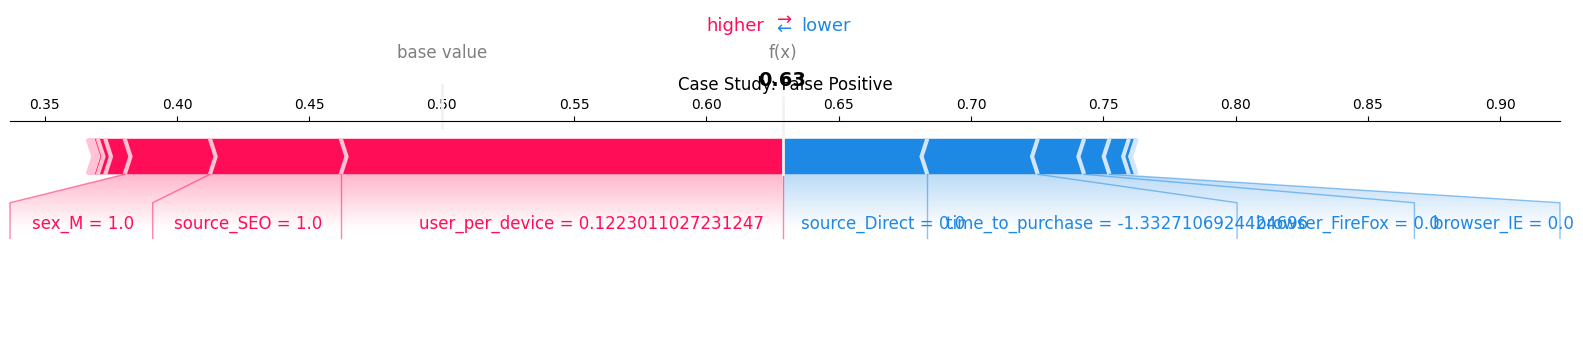

Analyzing False Negative...


<Figure size 1200x300 with 0 Axes>

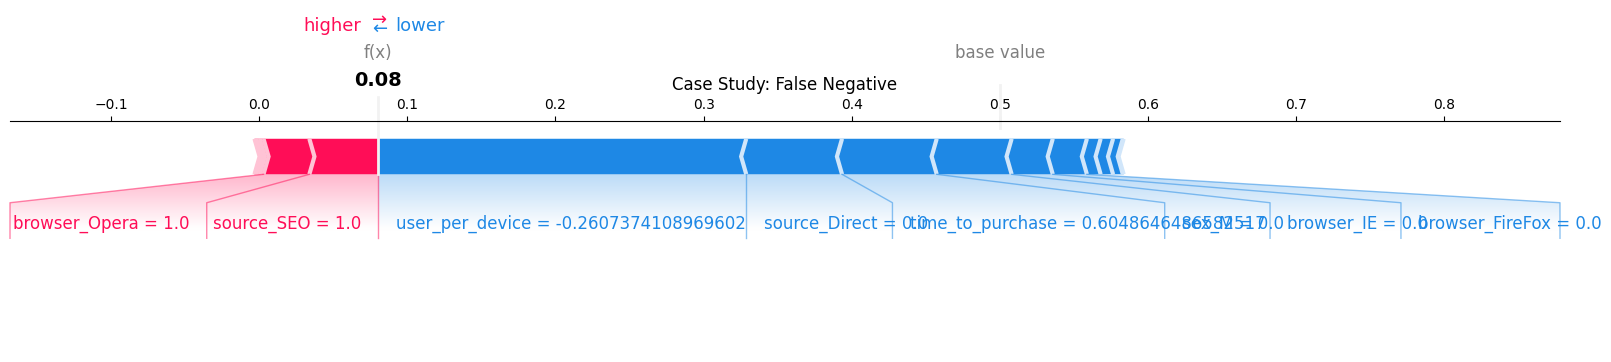

✅ TASK 3 FINISHED.


In [3]:
import sys, os, joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt, shap

# 1. Setup & Load (Assuming you already ran the previous setup cells)
model = joblib.load('../models/random_forest_model.pkl')
X_test = pd.read_csv('../data/processed/X_test_final.csv')
y_test = pd.read_csv('../data/processed/y_test_final.csv').values.ravel()

if hasattr(model, 'feature_names_in_'):
    X_test = X_test[model.feature_names_in_]

explainer = shap.TreeExplainer(model)

# 2. Find Case Indices
y_pred = model.predict(X_test)
res = pd.DataFrame({'actual': y_test, 'pred': y_pred})
indices = {
    "True Positive": res[(res.actual == 1) & (res.pred == 1)].index[0],
    "False Positive": res[(res.actual == 0) & (res.pred == 1)].index[0],
    "False Negative": res[(res.actual == 1) & (res.pred == 0)].index[0]
}

print("\n--- Visualizing Individual Cases with Dimension Guard ---")
shap.initjs()

for label, idx in indices.items():
    print(f"Analyzing {label}...")
    row_df = X_test.loc[[idx]]
    row_vals = row_df.iloc[0] # The features (1D)
    
    # Calculate SHAP values for THIS ROW
    raw_shap = explainer.shap_values(row_df)
    
    # --- THE SLICE (Fixes DimensionError) ---
    if isinstance(raw_shap, list):
        # Case A: SHAP returned a list of arrays (Standard for older RF)
        final_shap_values = raw_shap[1].flatten()
    elif len(raw_shap.shape) == 3:
        # Case B: SHAP returned a 3D array (1, num_features, 2)
        # We take: First sample [0], All features [:], Class 1 [1]
        final_shap_values = raw_shap[0, :, 1]
    else:
        # Case C: 2D array
        final_shap_values = raw_shap.flatten()

    # --- Verification Step ---
    if len(final_shap_values) != len(row_vals):
        print(f"⚠️ Warning: Dimension mismatch! SHAP: {len(final_shap_values)}, Features: {len(row_vals)}")
        # Emergency backup: just take the first N values
        final_shap_values = final_shap_values[:len(row_vals)]

    # 3. Plot
    plt.figure(figsize=(12, 3))
    # Extract base value safely
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    
    shap.force_plot(
        base_val, 
        final_shap_values, 
        row_vals, 
        matplotlib=True, 
        show=False
    )
    plt.title(f"Case Study: {label}")
    plt.show()

print("✅ TASK 3 FINISHED.")